In [64]:
!pip install -q xgboost lightgbm shap

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")

Libraries loaded.


In [65]:

train      = pd.read_csv("dataset_A_training.csv")
test       = pd.read_csv("dataset_A_testing.csv")

TARGET = "seasonal_vaccine"
ID     = "respondent_id"
print("train:", train.shape, "| test:", test.shape)
train.head()

train: (4756, 31) | test: (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.0,2.0,18 - 34 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,18 - 34 Years,Some College,White,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,1.0,65+ Years,College Graduate,White,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,3.0,1.0,55 - 64 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,3.0,1.0,1.0,55 - 64 Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [66]:
print("Shape:", train.shape)
print("\nColumn dtypes:")
print(train.dtypes.value_counts())
print("\nDuplicate respondent_id?", train[ID].duplicated().any())
display(train.describe(include="all").T.head(35))

Shape: (4756, 31)

Column dtypes:
float64    19
object     10
int64       2
Name: count, dtype: int64

Duplicate respondent_id? False


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,NaN,NaN,NaN,1.643128,0.91981,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,NaN,NaN,NaN,1.293049,0.618902,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.052299,0.222652,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,NaN,NaN,NaN,0.734124,0.441846,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,NaN,NaN,NaN,0.073848,0.261551,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.836563,0.369803,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.365494,0.481619,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,NaN,NaN,NaN,0.336634,0.472608,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,NaN,NaN,NaN,0.68841,0.463192,0.0,0.0,1.0,1.0,1.0


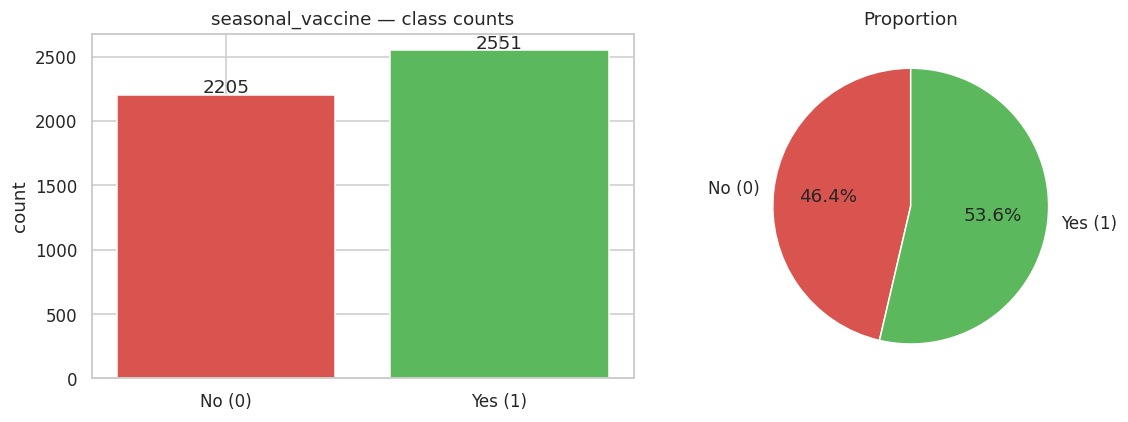

Positive rate = 0.536  ->  classes are well balanced.


In [67]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = train[TARGET].value_counts().sort_index()
ax[0].bar(["No (0)", "Yes (1)"], counts.values, color=["#d9534f", "#5cb85c"])
ax[0].set_title("seasonal_vaccine — class counts"); ax[0].set_ylabel("count")
for i, v in enumerate(counts.values): ax[0].text(i, v+15, str(v), ha="center")
ax[1].pie(counts.values, labels=["No (0)", "Yes (1)"], autopct="%1.1f%%",
          colors=["#d9534f", "#5cb85c"], startangle=90)
ax[1].set_title("Proportion")
plt.tight_layout(); plt.show()
print(f"Positive rate = {train[TARGET].mean():.3f}  ->  classes are well balanced.")

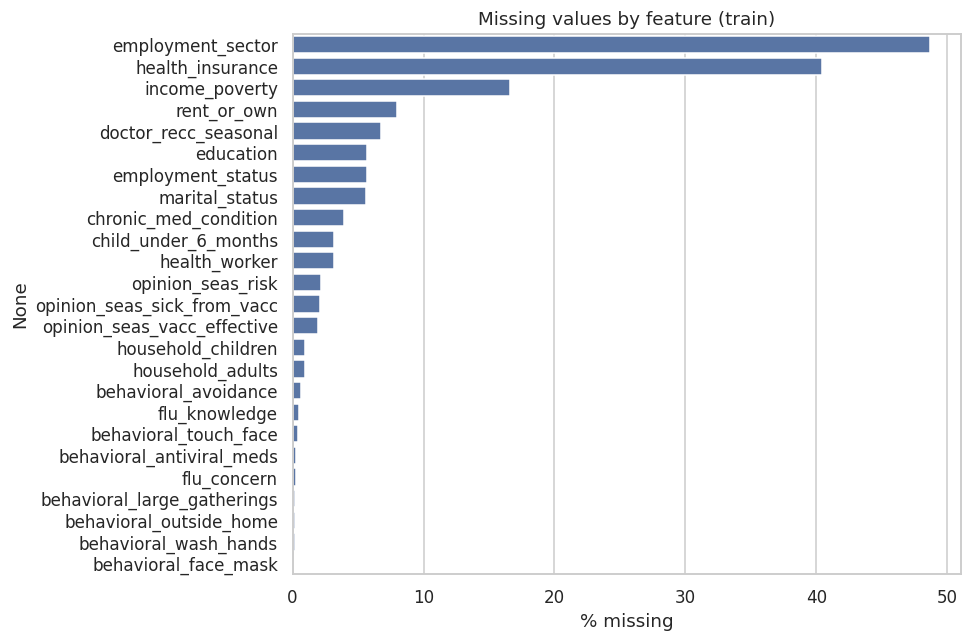

,percent_missing
employment_sector,48.7
health_insurance,40.5
income_poverty,16.6
rent_or_own,8.0
doctor_recc_seasonal,6.7
education,5.7
employment_status,5.7
marital_status,5.6
chronic_med_condition,4.0
child_under_6_months,3.2


In [68]:
miss = (train.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0]
plt.figure(figsize=(9, 6))
sns.barplot(x=miss.values, y=miss.index, color="#4c72b0")
plt.xlabel("% missing"); plt.title("Missing values by feature (train)")
plt.tight_layout(); plt.show()
display(miss.round(1).to_frame("percent_missing"))